# Nassau Candy Industries
## Factory-to-Customer Shipping Route Efficiency Analysis

In [78]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
df = pd.read_csv("/kaggle/input/datasets/ashura369/candy-dataset/Nassau Candy Distributor.csv")

In [81]:
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


---

<h2 align='center'>Feature Engineering for Visualization</h2>

### Dropping Unrequired Features
- `Row ID`
- `Order ID`
- `Product ID`

In [82]:
df.isna().sum().sum()

np.int64(0)

In [83]:
df.drop(columns=['Row ID','Order ID','Product ID'], inplace=True)

In [84]:
df.shape

(10194, 15)

---

### Feature Extraction

#### 1. `Order Date`
First converting `Order Date` into datetime format, then extracting `Month`, `DayName`, and `Quarter`.

In [85]:
# converting into datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'], format="%d-%m-%Y")

In [86]:
month = df['Order Date'].dt.month_name()
day = df['Order Date'].dt.day_name()
quarter = df['Order Date'].dt.quarter

In [87]:
df['Month'] = month.copy()
df['Day of Week'] = day.copy()
df['Quarter'] = quarter.copy()

In [88]:
df.dtypes

Order Date        datetime64[ns]
Ship Date                 object
Ship Mode                 object
Customer ID                int64
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Division                  object
Region                    object
Product Name              object
Sales                    float64
Units                      int64
Gross Profit             float64
Cost                     float64
Month                     object
Day of Week               object
Quarter                     int8
dtype: object

---

#### 2. `Sales`
Making `Sales Volume` feature.

In [89]:
df['Sales'].describe().reset_index()

,index,Sales
0,count,10194.000000
1,mean,13.908537
2,std,11.341020
3,min,1.250000
4,25%,7.200000
5,50%,10.800000
6,75%,18.000000
7,max,260.000000


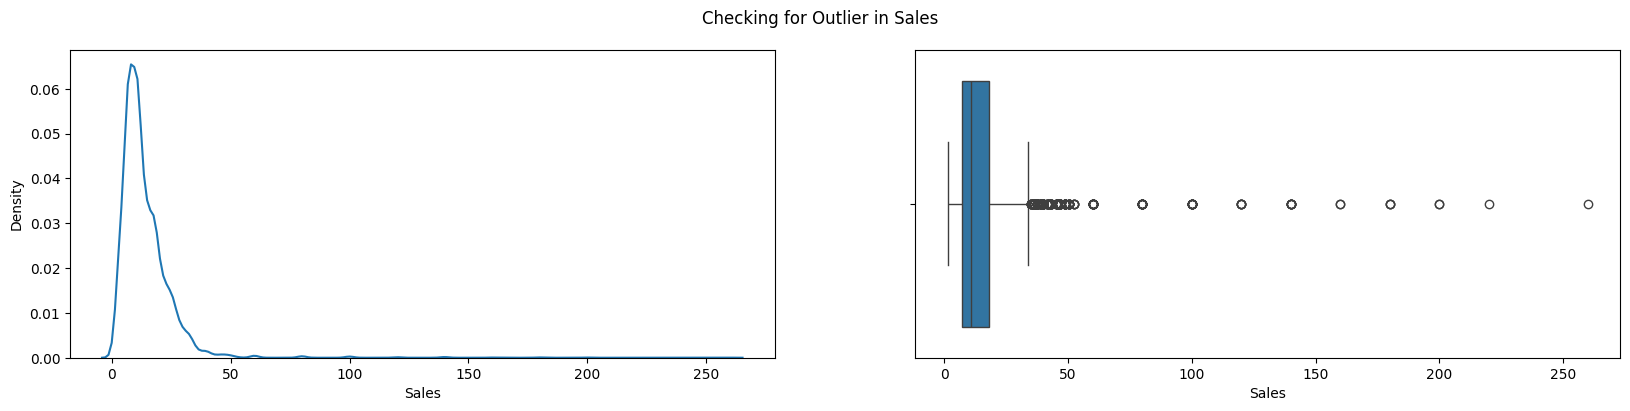

In [90]:
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.kdeplot(df['Sales'])
plt.subplot(122)
sns.boxplot(x=df['Sales'])
plt.suptitle("Checking for Outlier in Sales")
plt.show()

In [91]:
print(f"Total more than 50 in sales data : { df[df['Sales'] > 50]['Sales'].shape[0] }")
print(f"Total less than 50 in sales data : { df[df['Sales'] <= 50]['Sales'].shape[0] }")

Total more than 50 in sales data : 81
Total less than 50 in sales data : 10113


Applying Binning

In [92]:
bins = [1.25, 10.00, 30.00, 260.00]
labels = ['Low','Mid','High']

sales_volume = pd.cut(df['Sales'], bins=bins, labels=labels, include_lowest=True)

In [93]:
df['Sales Volume'] = sales_volume.copy()

---

#### `Gross Profit`
Making `Profit Volume` feature

In [94]:
df['Gross Profit'].describe().reset_index()

,index,Gross Profit
0,count,10194.000000
1,mean,9.166451
2,std,6.643740
3,min,0.250000
4,25%,4.900000
5,50%,7.470000
6,75%,12.250000
7,max,130.000000


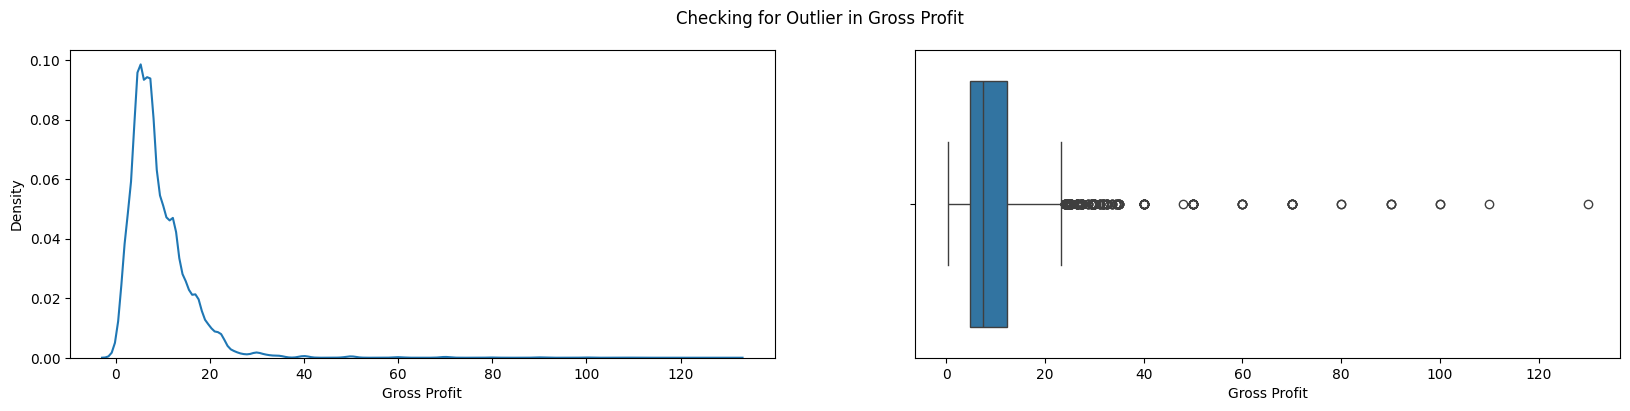

In [95]:
plt.figure(figsize=(20,4))
plt.subplot(121)
sns.kdeplot(df['Gross Profit'])
plt.subplot(122)
sns.boxplot(x=df['Gross Profit'])
plt.suptitle("Checking for Outlier in Gross Profit")
plt.show()

In [96]:
df[df['Gross Profit'] > 25]['Sales Volume'].unique()

['High']
Categories (3, object): ['Low' < 'Mid' < 'High']

Observation:
From above analysis, the observation that we can make is, when the profit goes more than 25 it is only because of `High` volume sales.

In [97]:
bins = [0.25,10.00,30.00,130.00]
labels = ['Small Profit','Medium Profit','High Profit']

profit_volume = pd.cut(df['Gross Profit'], bins=bins, labels=labels, include_lowest=True)

In [98]:
df['Profit Volume'] = profit_volume.copy()

---

<h2 align='center'>Feature Extraction</h2>

- `Cost`
    - `Price per unit` (sales / units)
    - `Profit per unit` (gross profit / units)
    - `Cost per unit` (cost / units)

In [99]:
price_unit = df['Sales'] / df['Units']
profit_unit = df['Gross Profit'] / df['Units']
cost_unit = df['Cost'] / df['Units']

In [100]:
df['Price per unit'] = price_unit.copy()
df['Profit per unit'] = profit_unit.copy()
df['Cost per unit'] = cost_unit.copy()

---

### `Shipping Lead Time` <br>
- The duration between when an order is placed and when it is shipped
- `Shipping Lead Time` = `Shipp Date` − `Order Date`
- **Negative Lead Times** : When Shipp Date is earlier than the Order Date (e.g., ordered on June 22, but shipped on June 15). Since you cannot ship an item before it is ordered, this is a data entry error and will skew your average shipping times.

In [101]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format="%d-%m-%Y")           # %y -- used when year is mentioned in two digits | %Y -- used when year is mentioned in four digits

In [102]:
shipping_lead_time = (df['Ship Date'] - df['Order Date']).dt.days

In [103]:
df['Shipping Lead Time'] = shipping_lead_time.copy()

In [104]:
with pd.option_context('display.max_columns', None):
    display(df.head(5))

,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product Name,Sales,Units,Gross Profit,Cost,Month,Day of Week,Quarter,Sales Volume,Profit Volume,Price per unit,Profit per unit,Cost per unit,Shipping Lead Time
0,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,January,Wednesday,1,Low,Small Profit,3.25,2.11,1.14,909
1,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,January,Thursday,1,Low,Small Profit,3.75,2.45,1.30,909
2,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,January,Thursday,1,Mid,Small Profit,3.49,2.49,1.00,909
3,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,January,Thursday,1,Mid,Small Profit,3.60,2.50,1.10,909
4,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,January,Friday,1,Mid,Small Profit,3.75,2.45,1.30,912


In [105]:
df['Shipping Lead Time'].unique()

array([ 909,  912,  906,  907,  910,  908,  911,  905,  904,  915, 1277,
       1272, 1275, 1276, 1274, 1273, 1271, 1270, 1269, 1638, 1639, 1635,
       1636, 1641, 1640, 1637, 1634, 1642])

In [106]:
df['Ship Mode'].unique()

array(['Standard Class', 'First Class', 'Second Class', 'Same Day'],
      dtype=object)

In [107]:
df[df['Ship Mode'] == 'Standard Class'][['Order Date','Ship Date','Shipping Lead Time']]

,Order Date,Ship Date,Shipping Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912
...,...,...,...
10189,2025-12-30,2030-06-26,1639
10190,2025-12-30,2030-06-26,1639
10191,2025-12-30,2030-06-26,1639
10192,2025-12-30,2030-06-26,1639


In [108]:
df[df['Ship Mode'] == 'First Class'][['Order Date','Ship Date','Shipping Lead Time']]

,Order Date,Ship Date,Shipping Lead Time
7,2024-01-06,2026-06-30,906
20,2024-01-11,2026-07-07,908
32,2024-01-14,2026-07-08,906
33,2024-01-15,2026-07-10,907
39,2024-01-19,2026-07-13,906
...,...,...,...
10121,2025-12-24,2030-06-17,1636
10126,2025-12-25,2030-06-20,1638
10144,2025-12-25,2030-06-20,1638
10153,2025-12-28,2030-06-23,1638


In [109]:
df[df['Ship Mode'] == 'Second Class'][['Order Date','Ship Date','Shipping Lead Time']]

,Order Date,Ship Date,Shipping Lead Time
11,2024-01-06,2026-07-01,907
22,2024-01-13,2026-07-09,908
25,2024-01-13,2026-07-08,907
26,2024-01-13,2026-07-08,907
27,2024-01-13,2026-07-08,907
...,...,...,...
10171,2025-12-29,2030-06-24,1638
10172,2025-12-29,2030-06-24,1638
10174,2025-12-29,2030-06-24,1638
10177,2025-12-29,2030-06-24,1638


In [110]:
df[df['Ship Mode'] == 'Same Day'][['Order Date','Ship Date','Shipping Lead Time']]

,Order Date,Ship Date,Shipping Lead Time
118,2024-02-18,2026-08-11,905
154,2024-03-04,2026-08-25,904
203,2024-03-17,2026-09-07,904
211,2024-03-17,2026-09-07,904
212,2024-03-17,2026-09-07,904
...,...,...,...
10054,2025-12-21,2030-06-13,1635
10097,2025-12-23,2030-06-15,1635
10149,2025-12-26,2030-06-18,1635
10150,2025-12-27,2030-06-19,1635


In [111]:
df[df['Shipping Lead Time'] < 0].shape[0]

0

In [112]:
df['Shipping Lead Time'].unique()

array([ 909,  912,  906,  907,  910,  908,  911,  905,  904,  915, 1277,
       1272, 1275, 1276, 1274, 1273, 1271, 1270, 1269, 1638, 1639, 1635,
       1636, 1641, 1640, 1637, 1634, 1642])

Observation : <br>
Since there is no Negative shipping leads, we will be moving forward with the data, But there is Definitely too much delays in late delivery.

### Making features for `Delay in Years`, and `Delay in Months`

In [123]:
df['Delay in Years'] = np.round(((df['Ship Date'] - df['Order Date']) / pd.Timedelta(days=365.25)).astype(float), 1)
 
df['Delay Months'] = (
    12 * (df['Ship Date'].dt.year - df['Order Date'].dt.year) + 
    (df['Ship Date'].dt.month - df['Order Date'].dt.month)
)

df['Delay in Days'] = (df['Ship Date'] - df['Order Date']).dt.days

Deleting "Shipping Lead Time", coz it is same as delay in days.

In [127]:
df.drop(columns=['Shipping Lead Time'], inplace=True)

---

### Standardizing Geographic Fields

In [131]:
df['State/Province'] = df['State/Province'].str.strip().str.title()
df['City'] = df['City'].str.strip().str.title()
df['Region'] = df['Region'].str.strip().str.title()
df['Country/Region'] = df['Country/Region'].str.strip().str.title()

---

<h2 align='center'>Renaming The Features</h2>

### Renaming the features and assigning them in a relative order

In [133]:
df.columns

Index(['Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region',
       'City', 'State/Province', 'Postal Code', 'Division', 'Region',
       'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost', 'Month',
       'Day of Week', 'Quarter', 'Sales Volume', 'Profit Volume',
       'Price per unit', 'Profit per unit', 'Cost per unit', 'Delay in Years',
       'Delay Months', 'Delay in Days'],
      dtype='object')

In [134]:
rename = {
    'Customer ID' : 'Customer ID',
    'Order Date' : 'Order Date',
    'Quarter' : 'Quarter',
    'Month' : 'Month',
    'Day of Week' : 'Day of Week',
    'Ship Date': 'Shipping Date',
    'Ship Mode': 'Shipping Mode',
    'Country/Region': 'Country',
    'State/Province': 'State',
    'Region' : 'Region',
    'City' : 'City',
    'Postal Code' : 'Postal Code',
    'Product Name' : 'Product Name',
    'Division': 'Product Category',
    'Units': 'Units Per Order',
    'Cost': 'Total Cost Per Order',
    'Sales': 'Sales Per Order',
    'Gross Profit': 'Gross Profit Per Order',
    'Sales Volume' : 'Sales Volume',
    'Profit Volume' : 'Profit Volume',
    'Price per unit' : 'Price Per Unit',
    'Profit per unit' : 'Profit Per Unit',
    'Cost per unit' : 'Cost Per Unit',
    'Delay in Years' : 'Delay in Years',
    'Delay in Months' : 'Delay in Months',
    'Delay in Days' : 'Delay in Days',
}

df = df.rename(columns=rename)



In [136]:
with pd.option_context('display.max_columns', None):
    display(df.sample(15))

,Order Date,Shipping Date,Shipping Mode,Customer ID,Country,City,State,Postal Code,Product Category,Region,Product Name,Sales Per Order,Units Per Order,Gross Profit Per Order,Total Cost Per Order,Month,Day of Week,Quarter,Sales Volume,Profit Volume,Price Per Unit,Profit Per Unit,Cost Per Unit,Delay in Years,Delay Months,Delay in Days
7253,2025-03-23,2029-09-17,Standard Class,135650,United States,Huntsville,Texas,77340,Chocolate,Interior,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,March,Sunday,1,Low,Small Profit,3.75,2.45,1.30,4.5,54,1639
2533,2024-05-12,2027-11-06,Standard Class,159380,United States,San Francisco,California,94122,Chocolate,Pacific,Wonka Bar - Nutty Crunch Surprise,20.94,6,14.94,6.00,May,Sunday,2,Mid,Medium Profit,3.49,2.49,1.00,3.5,42,1273
8605,2025-09-09,2030-03-06,Standard Class,118087,United States,Philadelphia,Pennsylvania,19134,Chocolate,Atlantic,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,September,Tuesday,3,Low,Small Profit,3.75,2.45,1.30,4.5,54,1639
6023,2025-10-22,2029-04-15,First Class,116400,United States,Richmond,Virginia,23223,Chocolate,Gulf,Wonka Bar - Fudge Mallows,14.40,4,9.60,4.80,October,Wednesday,4,Mid,Small Profit,3.60,2.40,1.20,3.5,42,1271
569,2024-06-02,2026-11-28,Standard Class,104472,United States,Orem,Utah,84057,Chocolate,Pacific,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,June,Sunday,2,Mid,Small Profit,3.49,2.49,1.00,2.5,29,909
4145,2024-12-27,2028-06-22,Standard Class,148376,United States,Los Angeles,California,90008,Chocolate,Pacific,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,December,Friday,4,Low,Small Profit,3.25,2.11,1.14,3.5,42,1273
163,2024-03-07,2026-09-02,Standard Class,104563,United States,Seattle,Washington,98103,Chocolate,Pacific,Wonka Bar -Scrumdiddlyumptious,18.00,5,12.50,5.50,March,Thursday,1,Mid,Medium Profit,3.60,2.50,1.10,2.5,30,909
9930,2025-12-10,2030-06-04,First Class,143798,United States,Philadelphia,Pennsylvania,19140,Chocolate,Atlantic,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,December,Wednesday,4,Low,Small Profit,3.75,2.45,1.30,4.5,54,1637
7850,2025-06-10,2029-12-05,Standard Class,107167,United States,Jacksonville,Florida,32216,Chocolate,Gulf,Wonka Bar - Milk Chocolate,26.00,8,16.88,9.12,June,Tuesday,2,Mid,Medium Profit,3.25,2.11,1.14,4.5,54,1639
8702,2025-09-15,2030-03-14,Standard Class,163300,United States,Los Angeles,California,90049,Chocolate,Pacific,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,September,Monday,3,Mid,Small Profit,3.75,2.45,1.30,4.5,54,1641


---

### Saving the dataset

In [137]:
df.to_csv('Nassau Candy Distributor Visualisation.csv', index=False)